In [113]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Preparación del entorno

In [114]:
df = pd.read_csv('datos_tratados.csv')
df

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,No,Female,No,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,9992-RRAMN,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,9992-UJOEL,No,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,9993-LHIEB,No,Male,No,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


In [115]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [117]:
df = df.drop(columns=['CustomerID'])
df.sample(5)


,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
4173,Yes,Female,No,No,No,13,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,2.50,75.00,999.45
2490,No,Male,No,No,No,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.52,45.55,45.55
5266,No,Male,No,Yes,No,33,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,3.11,93.35,3092.00
906,Yes,Female,No,No,No,3,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,2.52,75.50,220.60
6111,Yes,Female,Yes,No,No,60,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,3.53,106.00,6441.40


In [118]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No'})

df[cols_to_fix]
df.sample(5)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
2881,No,Male,Yes,Yes,No,29,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,1.72,51.60,1442.00
391,Yes,Female,No,Yes,Yes,22,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,No,Electronic check,2.78,83.30,1845.90
3707,No,Female,No,Yes,Yes,7,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,0.82,24.70,149.05
269,No,Male,No,No,No,67,Yes,No,No,No,...,No,No,No,No,Two year,No,Bank transfer (automatic),0.68,20.50,1430.95
2126,No,Female,No,No,No,63,Yes,No,DSL,No,...,Yes,No,No,Yes,One year,No,Credit card (automatic),1.95,58.55,3503.50


In [119]:
for col in df.columns:
  if df[col].nunique() <= 10:
    unique_values = df[col].unique()
    print("-"*50)
    print(f"Valores únicos en la columna '{col}': {unique_values}")
  else:
    print("-"*50)
    print(f"La columna '{col}' tiene {df[col].nunique()} valores únicos")

--------------------------------------------------
Valores únicos en la columna 'Churn': ['No' 'Yes']
--------------------------------------------------
Valores únicos en la columna 'Gender': ['Female' 'Male']
--------------------------------------------------
Valores únicos en la columna 'SeniorCitizen': ['No' 'Yes']
--------------------------------------------------
Valores únicos en la columna 'Partner': ['Yes' 'No']
--------------------------------------------------
Valores únicos en la columna 'Dependents': ['Yes' 'No']
--------------------------------------------------
La columna 'Tenure' tiene 73 valores únicos
--------------------------------------------------
Valores únicos en la columna 'PhoneService': ['Yes' 'No']
--------------------------------------------------
Valores únicos en la columna 'MultipleLines': ['No' 'Yes']
--------------------------------------------------
Valores únicos en la columna 'InternetService': ['DSL' 'Fiber optic' 'No']
-----------------------------

In [120]:
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [121]:
df.describe()

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,2.158675,64.761692,2279.734304
std,24.559481,1.003088,30.090047,2266.794470
min,0.000000,0.610000,18.250000,0.000000
25%,9.000000,1.180000,35.500000,398.550000
50%,29.000000,2.340000,70.350000,1394.550000
75%,55.000000,2.990000,89.850000,3786.600000
max,72.000000,3.960000,118.750000,8684.800000


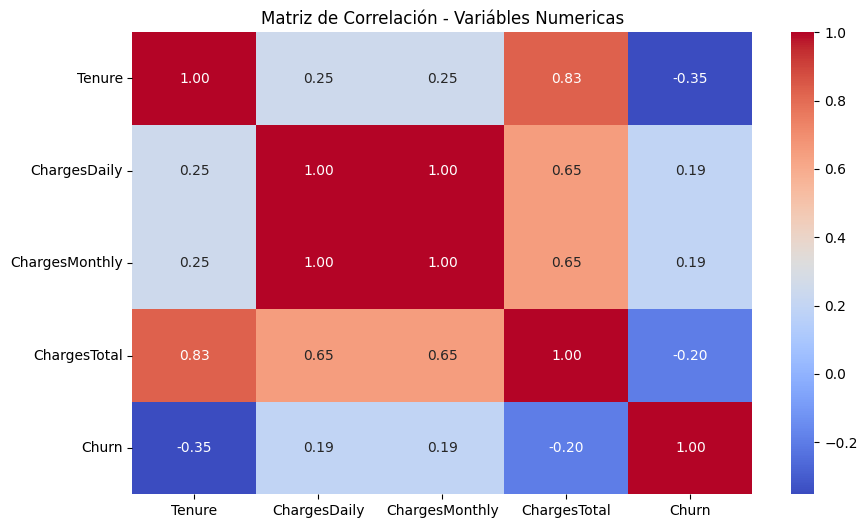

In [122]:
df_numeric = df.select_dtypes(include=["int64", "float64"])
df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
corr_matrix = df_numeric.corr()

#Visualización
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()

In [123]:

print("Correlación entre variables numéricas:")
print(corr_matrix[['ChargesDaily', 'ChargesMonthly', 'ChargesTotal']].round(2))

df = df.drop(columns=['ChargesDaily', 'ChargesTotal'])
print("Columnas redundantes eliminadas por multicolinealidad")

Correlación entre variables numéricas:
                ChargesDaily  ChargesMonthly  ChargesTotal
Tenure                  0.25            0.25          0.83
ChargesDaily            1.00            1.00          0.65
ChargesMonthly          1.00            1.00          0.65
ChargesTotal            0.65            0.65          1.00
Churn                   0.19            0.19         -0.20
Columnas redundantes eliminadas por multicolinealidad


In [124]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")
for col in categorical_cols:
    print(f"variable: {col}")
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)

variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [125]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

df_rank = df.copy()

df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

categorical_cols = df_rank.select_dtypes(include=["object"]).columns

le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

chi_scores, p_values = chi2(X_cat, y)

chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df

,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [126]:
significant_vars = chi_df[chi_df["p-value"] < 0.05]

print("\nSignificant variables (p < 0.05):")
display(significant_vars)


Significant variables (p < 0.05):


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [127]:
df = df.drop(columns=["Gender", "PhoneService"])
df

,Churn,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,No,Yes,Yes,9,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60
1,No,No,No,No,9,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90
2,Yes,No,No,No,4,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90
3,Yes,Yes,Yes,No,13,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00
4,Yes,Yes,Yes,No,3,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,No,No,No,13,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15
7039,Yes,No,Yes,No,22,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10
7040,No,No,No,No,2,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30
7041,No,No,Yes,Yes,67,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85


In [128]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
    )


In [129]:

X_train = pd.get_dummies(X_train, drop_first=True)


X_test = pd.get_dummies(X_test, drop_first=True)


X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


X_train.head()

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3793,60,94.10,False,True,False,True,True,False,True,True,False,False,False,True,False,False,True,True,False,False
3192,12,19.35,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4922,2,80.45,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False
3926,33,74.75,False,True,True,False,False,False,True,False,True,False,True,True,True,False,False,True,False,False
3859,14,86.00,False,False,True,True,True,False,True,False,False,True,False,False,False,False,True,False,False,True


In [130]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3793 to 5679
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 5634 non-null   int64  
 1   ChargesMonthly                         5634 non-null   float64
 2   SeniorCitizen_Yes                      5634 non-null   bool   
 3   Partner_Yes                            5634 non-null   bool   
 4   Dependents_Yes                         5634 non-null   bool   
 5   MultipleLines_Yes                      5634 non-null   bool   
 6   InternetService_Fiber optic            5634 non-null   bool   
 7   InternetService_No                     5634 non-null   bool   
 8   OnlineSecurity_Yes                     5634 non-null   bool   
 9   OnlineBackup_Yes                       5634 non-null   bool   
 10  DeviceProtection_Yes                   5634 non-null   bool   
 11  TechSu

In [131]:
resumen_balance = (y_train.value_counts(normalize=True) * 100).to_frame(name='Proporción (%)')
display(resumen_balance.style.format("{:.2f}%"))

,Proporción (%)
Churn,
No,73.46%
Yes,26.54%


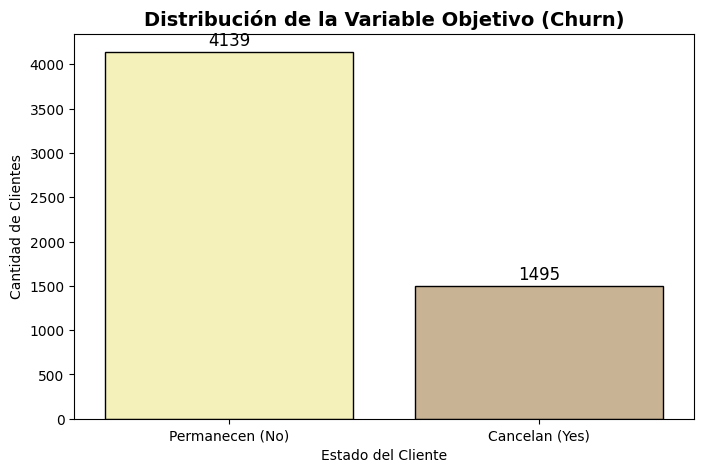

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))


ax = sns.countplot(
    x=y_train,
    hue=y_train,
    palette={'No': "#FFF9B1", 'Yes': "#D2B48C"},
    edgecolor="black",
    legend=False
)

plt.title('Distribución de la Variable Objetivo (Churn)', fontsize=14, fontweight='bold')


plt.xticks(['No', 'Yes'], ['Permanecen (No)', 'Cancelan (Yes)'])

plt.xlabel('Estado del Cliente')
plt.ylabel('Cantidad de Clientes')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='baseline',
                    fontsize=12, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.show()

In [133]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

col_numeric = df.select_dtypes(include=["int64", "float64"]).columns
col_numeric

Index(['Tenure', 'ChargesMonthly'], dtype='object')

In [134]:
scaler = MinMaxScaler()

X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

X_train_norm[col_numeric] = scaler.fit_transform(X_train[col_numeric])
X_test_norm[col_numeric] = scaler.transform(X_test[col_numeric])

X_train_norm[col_numeric].describe()

,Tenure,ChargesMonthly
count,5634.000000,5634.000000
mean,0.449301,0.464700
std,0.341426,0.299184
min,0.000000,0.000000
25%,0.125000,0.198430
50%,0.402778,0.519432
75%,0.763889,0.712506
max,1.000000,1.000000


# Correlación y Selección de Variables

In [135]:

X_train = pd.get_dummies(X_train, drop_first=True)
X_train_norm = pd.get_dummies(X_train_norm, drop_first=True)



X_test = pd.get_dummies(X_test, drop_first=True)
X_test_norm = pd.get_dummies(X_test_norm, drop_first=True)



X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
X_train_norm, X_test_norm = X_train_norm.align(X_test_norm, join='left', axis=1, fill_value=0)

X_train.head()

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3793,60,94.10,False,True,False,True,True,False,True,True,False,False,False,True,False,False,True,True,False,False
3192,12,19.35,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4922,2,80.45,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False
3926,33,74.75,False,True,True,False,False,False,True,False,True,False,True,True,True,False,False,True,False,False
3859,14,86.00,False,False,True,True,True,False,True,False,False,True,False,False,False,False,True,False,False,True


In [136]:
temp_df = X_train.copy()
temp_df['Churn'] = y_train.map({'Yes': 1, 'No': 0})

plt.figure(figsize=(12, 8))
correlation = temp_df.corr()

correlation['Churn']

,Churn
Tenure,-0.351948
ChargesMonthly,0.188884
SeniorCitizen_Yes,0.153134
Partner_Yes,-0.152032
Dependents_Yes,-0.158042
MultipleLines_Yes,0.042973
InternetService_Fiber optic,0.303902
InternetService_No,-0.225631
OnlineSecurity_Yes,-0.168577
OnlineBackup_Yes,-0.086360


<Figure size 1200x800 with 0 Axes>

In [137]:
temp_df[temp_df['Churn']==1].describe()

,Tenure,ChargesMonthly,Churn
count,1495.000000,1495.000000,1495.0
mean,17.955184,74.467659,1.0
std,19.536154,24.518907,0.0
min,1.000000,18.850000,1.0
25%,2.000000,56.675000,1.0
50%,10.000000,79.600000,1.0
75%,29.000000,94.200000,1.0
max,72.000000,118.350000,1.0


# **Desarrollo y comparacion de modelos**

In [138]:
#Model 1
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model_normal = LogisticRegression(max_iter=1000)
log_model_normal.fit(X_train, y_train)
y_pred_log_normal = log_model_normal.predict(X_test)

print("Regresion logistica")
print(classification_report(y_test, y_pred_log_normal))

Regresion logistica
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [139]:
#Model 2
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1035
         Yes       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [140]:
#Model 3
log_model_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model_balanced.fit(X_train, y_train)
y_pred_log = log_model_balanced.predict(X_test)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

          No       0.90      0.73      0.81      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



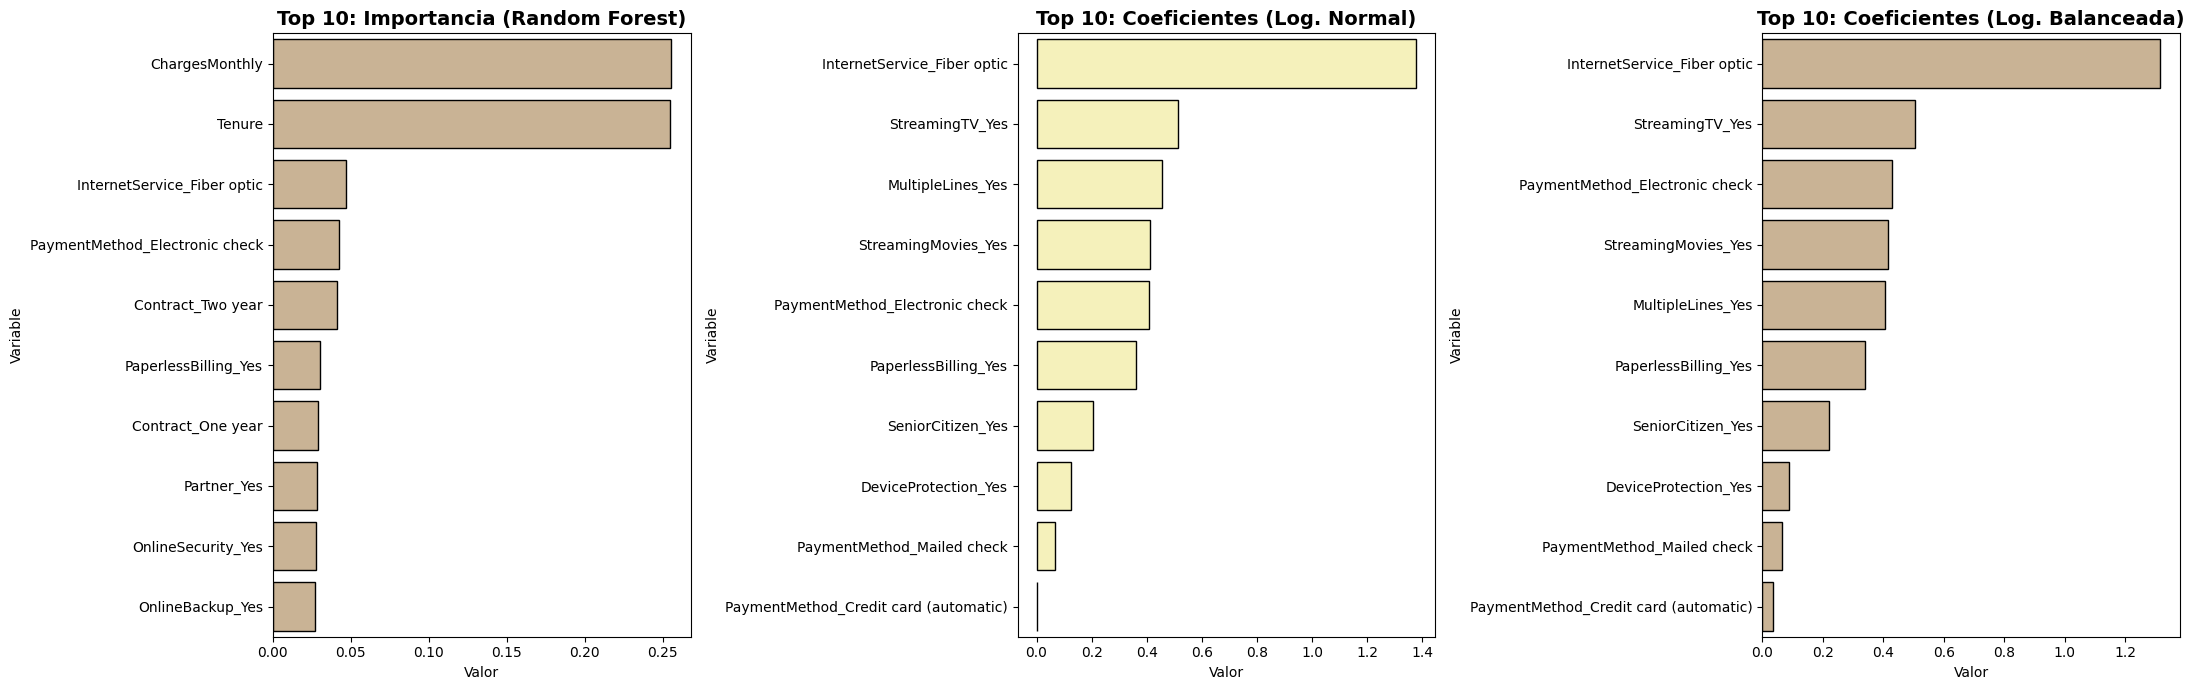

In [141]:
rf_importances = pd.DataFrame({
    'Variable': X_train.columns,
    'Valor': rf_model.feature_importances_
}).sort_values(by='Valor', ascending=False)

log_normal_coeffs = pd.DataFrame({
    'Variable': X_train.columns,
    'Valor': log_model_normal.coef_[0]
}).sort_values(by='Valor', ascending=False)

log_balanced_coeffs = pd.DataFrame({
    'Variable': X_train.columns,
    'Valor': log_model_balanced.coef_[0]
}).sort_values(by='Valor', ascending=False)



fig, ax = plt.subplots(1, 3, figsize=(22, 7))


sns.barplot(x='Valor', y='Variable', data=rf_importances.head(10), ax=ax[0], color='#D2B48C', edgecolor="black")
ax[0].set_title('Top 10: Importancia (Random Forest)', fontsize=14, fontweight='bold')


sns.barplot(x='Valor', y='Variable', data=log_normal_coeffs.head(10), ax=ax[1], color='#FFF9B1', edgecolor="black")
ax[1].set_title('Top 10: Coeficientes (Log. Normal)', fontsize=14, fontweight='bold')


sns.barplot(x='Valor', y='Variable', data=log_balanced_coeffs.head(10), ax=ax[2], color='#D2B48C', edgecolor="black")
ax[2].set_title('Top 10: Coeficientes (Log. Balanceada)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [142]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

print("="*80)
print("VALIDACIÓN CRUZADA (5-FOLD)")
print("="*80)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


modelo_cv = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)


scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label='Yes', zero_division=0),
    'recall':    make_scorer(recall_score,    pos_label='Yes', zero_division=0),
    'f1':        make_scorer(f1_score,        pos_label='Yes', zero_division=0),
    'roc_auc':   'roc_auc'
}


print("\n⏳ Ejecutando validación cruzada...")
cv_results = cross_validate(
    modelo_cv,
    X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

print("Validación completada\n")


print("RESULTADOS DE VALIDACIÓN CRUZADA:")
print("-" * 80)

metricas_cv = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

for metrica in metricas_cv:
    train_scores = cv_results[f'train_{metrica}']
    test_scores = cv_results[f'test_{metrica}']

    print(f"{metrica.upper():10s}:")
    print(f"   Train: {train_scores.mean():.3f} (+/- {train_scores.std():.3f})")
    print(f"   Test:  {test_scores.mean():.3f} (+/- {test_scores.std():.3f})")
    print(f"   Diff:  {train_scores.mean() - test_scores.mean():.3f}")
    print()


VALIDACIÓN CRUZADA (5-FOLD)

⏳ Ejecutando validación cruzada...
Validación completada

RESULTADOS DE VALIDACIÓN CRUZADA:
--------------------------------------------------------------------------------
ACCURACY  :
   Train: 0.753 (+/- 0.005)
   Test:  0.750 (+/- 0.012)
   Diff:  0.003

PRECISION :
   Train: 0.523 (+/- 0.007)
   Test:  0.519 (+/- 0.015)
   Diff:  0.004

RECALL    :
   Train: 0.800 (+/- 0.002)
   Test:  0.795 (+/- 0.013)
   Diff:  0.006

F1        :
   Train: 0.632 (+/- 0.005)
   Test:  0.628 (+/- 0.013)
   Diff:  0.005

ROC_AUC   :
   Train: 0.847 (+/- 0.004)
   Test:  0.843 (+/- 0.017)
   Diff:  0.004



## Conclusión

📄 Informe Final de Análisis de Evasión: Telecom X
1. Desempeño y Rendimiento de los Modelos
Para abordar el problema de la evasión, se evaluaron tres arquitecturas de modelos. La selección del modelo final se basó no solo en la precisión global, sino en la capacidad de detección preventiva.

Regresión Logística (Normal): Logró un Accuracy del 80%, pero con una cobertura limitada sobre la clase de clientes que cancelan.

Random Forest: Alcanzó un Accuracy del 77.6% y un F1-Score de 0.64. Es el modelo más robusto para identificar la jerarquía de variables y capturar relaciones no lineales entre servicios.

Regresión Logística (Balanceada) - MODELO FINAL: Aunque su Accuracy es ligeramente menor (74.45%), se seleccionó como el modelo definitivo debido a su Sensibilidad (Recall) del 79%.

Justificación Técnica: En un problema de Churn, el costo de no detectar a un cliente que se va (falso negativo) es mucho más alto que el costo de una falsa alarma. Este modelo minimiza ese riesgo, identificando correctamente a casi 8 de cada 10 clientes en peligro de fuga.

2. Factores que influyen en la Cancelación (Drivers de Churn)
Basándose en los coeficientes del modelo y la importancia de variables, se identificaron los factores críticos:

🔴 Factores de Alto Riesgo (Aumentan el Churn)
Tipo de Contrato (Mes a Mes): Es el predictor más poderoso. Los clientes sin compromiso a largo plazo tienen una tasa de cancelación del 42.7%.

Internet de Fibra Óptica: Sorprendentemente, los clientes de fibra cancelan más (42%) que los de DSL (19%), lo que sugiere una brecha entre el alto costo y la calidad percibida o estabilidad del servicio.

Método de Pago (Electronic Check): Asociado a la tasa de cancelación más alta (45.3%), indicando un perfil de cliente menos automatizado y más propenso a la volatilidad.

Antigüedad (Tenure Bajo): Los primeros 6 a 12 meses representan la "zona de muerte". La falta de lealtad histórica hace que cualquier fricción resulte en cancelación.

🟢 Factores Protectores (Reducen el Churn)
Contratos a Largo Plazo (1 y 2 años): Reducen el riesgo drásticamente (solo 2.8% de churn en contratos de 2 años).

Servicios de Valor Agregado: El Soporte Técnico (TechSupport) y la Seguridad en Línea (OnlineSecurity) actúan como anclas, reduciendo la deserción a la mitad.

3. Identificación del Perfil de Cliente en Riesgo
El equipo de retención debe priorizar a los usuarios que cumplan con este perfil:

Contrato mensual con menos de un año de antigüedad.

Servicio de Internet por Fibra Óptica con cargos mensuales elevados.

Pago mediante cheque electrónico y sin servicios de seguridad o soporte técnico contratados.

4. Estrategias de Retención Propuestas
Basándose en los hallazgos, se proponen las siguientes acciones estratégicas:

📌 Estrategia de Migración Contractual: Implementar campañas de marketing para mover a los clientes "mes a mes" hacia contratos anuales mediante descuentos progresivos. El objetivo es convertir la volatilidad en estabilidad financiera.

📌 Plan de Onboarding Crítico: Crear un protocolo de atención especial para los clientes en sus primeros 6 meses. Un contacto proactivo y tutoriales de uso pueden reducir la frustración inicial que lleva al abandono temprano.

📌 Auditoría de Fibra Óptica: Realizar encuestas de satisfacción (NPS) específicas para usuarios de fibra. Es necesario investigar si el problema es técnico (caídas del servicio) o comercial (precio vs. competencia).

📌 Venta Cruzada (Cross-selling) como Ancla: Ofrecer servicios de Tech Support y Online Security de forma gratuita por tiempo limitado (ej. 3 meses) a clientes de fibra óptica. Estos servicios aumentan el valor percibido y dificultan la decisión de cancelar.

📌 Incentivos de Automatización de Pagos: Ofrecer pequeños bonos o descuentos en la factura por migrar del "Electronic Check" a métodos de pago automáticos (tarjeta o débito), fomentando la retención pasiva.

5. Conclusión General
La deserción en Telecom X no es aleatoria; responde a patrones claros de estructura contractual y experiencia temprana. Mientras que el Random Forest nos permite entender la complejidad de los datos, la Regresión Logística Balanceada nos da la herramienta operativa para actuar. Implementar estos modelos en un sistema de scoring mensual permitirá a la empresa intervenir proactivamente sobre la cartera de clientes, transformando una pérdida de ingresos potencial en una oportunidad de fidelización.